In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')
titanic = pd.read_csv('/content/drive/MyDrive/dane/titanic.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Poniżej przedstawiam rozkłady zmiennych oraz braki danych w zbiorze.

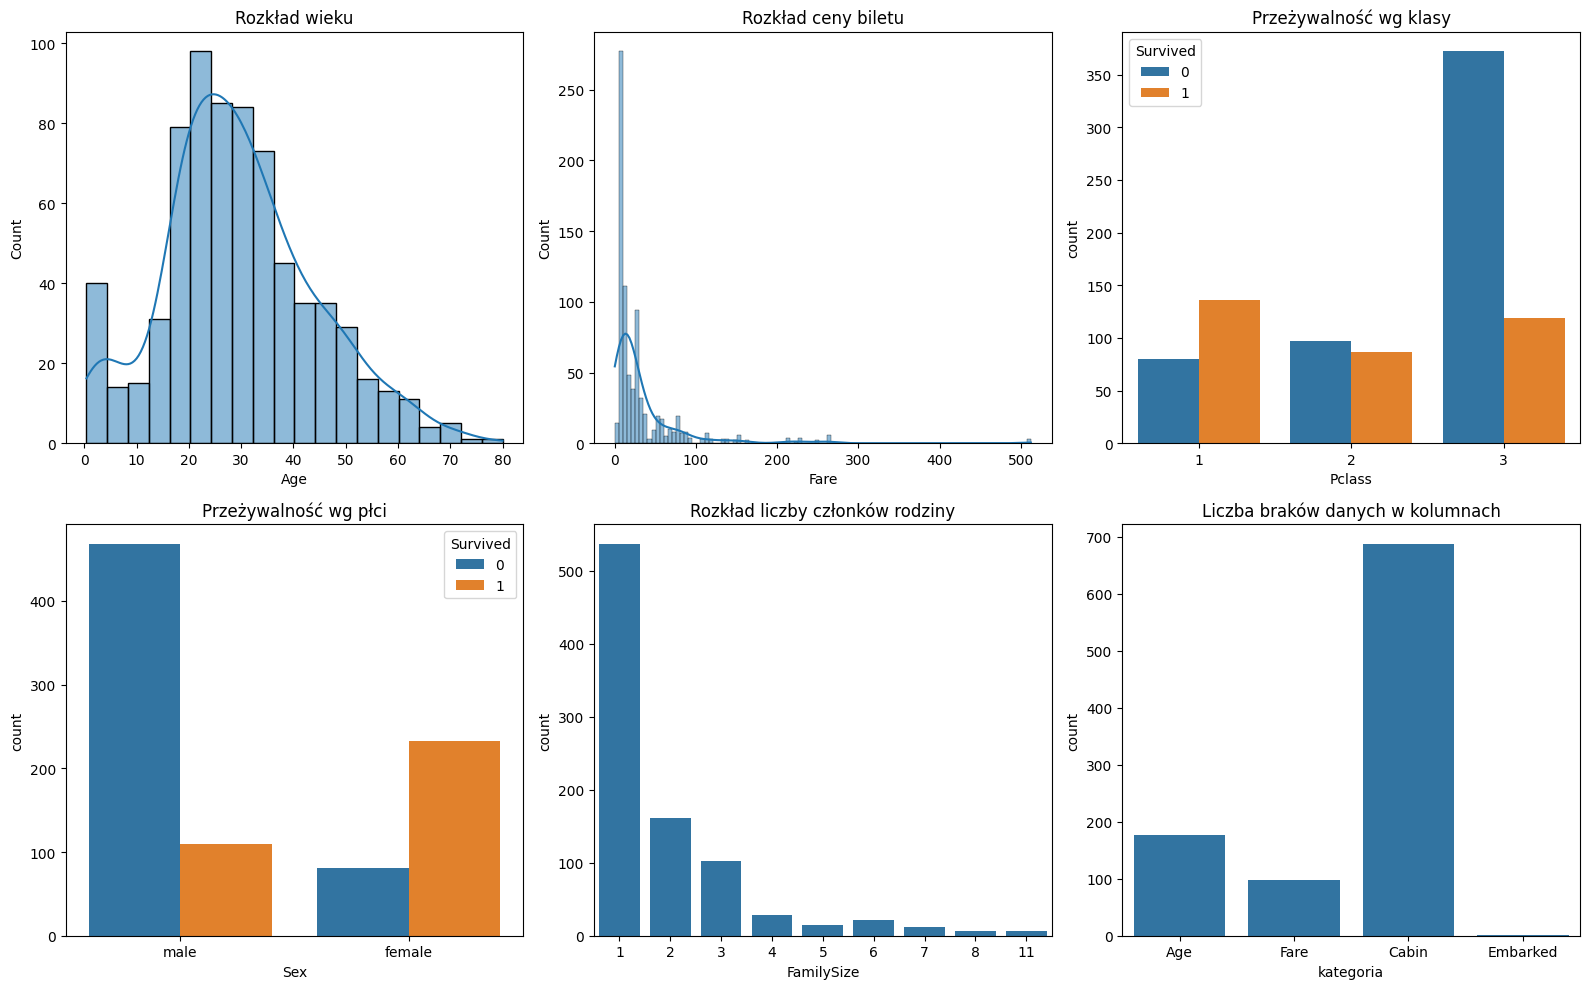

In [2]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

sns.histplot(titanic['Age'].dropna(), kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Rozkład wieku')

sns.histplot(titanic['Fare'].dropna(), kde=True, ax=axes[0, 1])
axes[0, 1].set_title('Rozkład ceny biletu')

sns.countplot(data=titanic, x='Pclass', hue='Survived', ax=axes[0, 2])
axes[0, 2].set_title('Przeżywalność wg klasy')

sns.countplot(data=titanic, x='Sex', hue='Survived', ax=axes[1, 0])
axes[1, 0].set_title('Przeżywalność wg płci')

# Liczymy członków pojedynczej rodziny sumując ze sobą 'SibSp' oraz 'Parch' i zastępujemy nią te dwie kolumny.
titanic['FamilySize'] = titanic['SibSp'] + titanic['Parch'] + 1
titanic = titanic.drop(columns=['SibSp', 'Parch'])
sns.countplot(x=titanic['FamilySize'], ax=axes[1, 1],)
axes[1, 1].set_title('Rozkład liczby członków rodziny')

missing = titanic.isnull().sum()
missing = missing[missing > 0]
missing.index.name = "kategoria"
sns.barplot(x=missing.index, y=missing.values, ax=axes[1, 2])
axes[1, 2].set_title('Liczba braków danych w kolumnach')
axes[1, 2].set_ylabel('count')

plt.tight_layout()
plt.show()

Braki stanowią aż 78% kolumn dotyczących przydzielenia pasażerów do kabin. Może to wynikać z tego, że nie dokumentowano przypisanych kabin w tych najniższych klasach, więc zastąpimy ją kolumną określającą czy dany pasażer został przydzielony do jakiejkolwiek kabiny czy też nie/nie wiadomo. Widzimy również że znaczna większość mężczyzn nie przeżyła, historycznie ma to przełożenie na to, że w tamtych czasach kobiety oraz dzieci miały pierwszeństwo podczas ewakuacji. Większość podróżujących podróżowało w klasie trzeciej, najtańszej, znajdującej się na najniższych pokładach, co również przyczyniło się do tak niskiej przeżywalności w tamtej klasie.

In [3]:
titanic['Has_Cabin'] = titanic['Cabin'].notna().astype(int)
titanic = titanic.drop(columns=['Cabin'])

Teraz kodujemy płeć, if female: sex = 0, man: sex = 1

In [4]:
titanic['Sex'] = titanic['Sex'].map({
    'male': 1, 'female': 0
})

Podejmuję decyzję o usunięciu kolumny 'Ticket', 'Name' oraz 'PassengerId', ponieważ nie jestem w stanie odpowiednio zakodować tych kolumn i nie uważam by niosły wartość istotną dla dalszej analizy. Traktuję je jako zbędne.

In [5]:
titanic = titanic.drop(columns=['Ticket', 'Name', 'PassengerId'])


1. Kodujemy kolumnę 'Embarked' za pomocą one-hot encoding i uzupełniamy jej braki najczęstszą wartością (modą).
2. Braki wiekowe uzupełniamy przewidując losowo z istniejącego rozkładu. (wykorzystujemy random seed)
3. Kolumnę 'Fare' uzupełniamy medianą cen dla poszczególnej klasy.

In [6]:
titanic['Embarked'] = titanic['Embarked'].fillna(titanic['Embarked'].mode()[0])
titanic = pd.get_dummies(titanic, columns=['Embarked'], prefix='Embarked', dtype=int)

np.random.seed(2137) #hehe
age = titanic['Age'].dropna()
titanic['Age'] = titanic['Age'].apply(lambda x: np.random.choice(age) if pd.isna(x) else x)

titanic['Fare'] = titanic['Fare'].fillna(titanic.groupby('Pclass')['Fare'].transform('median'))

Prezentacja gotowej tabeli

In [7]:
display(titanic)

,Survived,Pclass,Sex,Age,Fare,FamilySize,Has_Cabin,Embarked_C,Embarked_Q,Embarked_S
0,0,3,1,22.0,7.2500,2,0,0,0,1
1,1,1,0,38.0,71.2833,2,1,1,0,0
2,1,3,0,26.0,7.9250,1,0,0,0,1
3,1,1,0,35.0,53.1000,2,1,0,0,1
4,0,3,1,35.0,8.0500,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...
886,0,2,1,27.0,13.0000,1,0,0,0,1
887,1,1,0,19.0,30.0000,1,1,0,0,1
888,0,3,0,44.0,23.4500,4,0,0,0,1
889,1,1,1,26.0,30.0000,1,1,1,0,0


Zbadajmy teraz outliery w Fare i Age

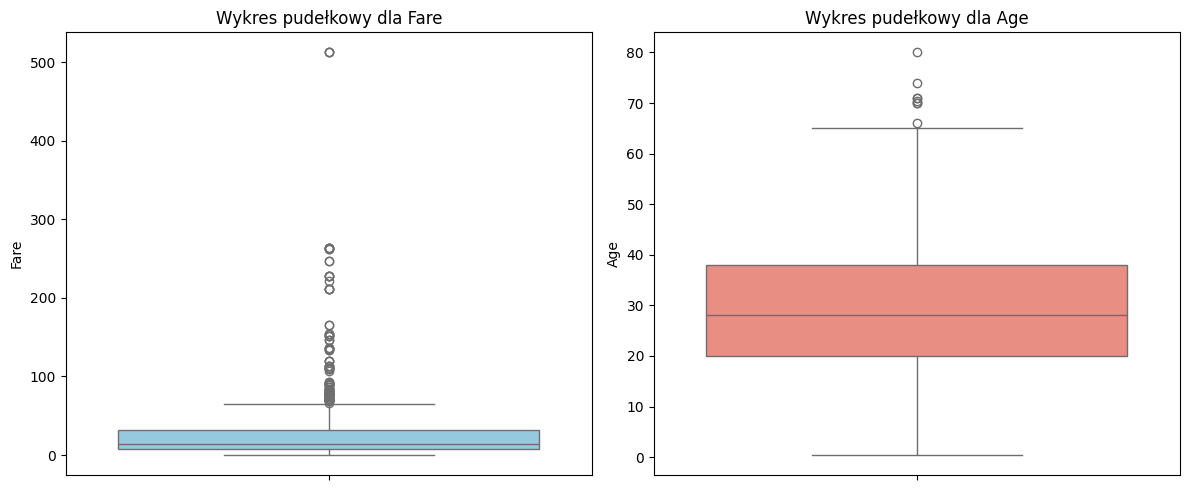

In [8]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(y=titanic['Fare'], color='skyblue')
plt.title('Wykres pudełkowy dla Fare')

plt.subplot(1, 2, 2)
sns.boxplot(y=titanic['Age'], color='salmon')
plt.title('Wykres pudełkowy dla Age')

plt.tight_layout()
plt.show()

Widzimy tutaj bardzo skrajną wartość ceny biletu wynoszącą ponad 500 dolarów, prawdopodobnie był to najdroższy bilet na Titanicu powiązany z jakimś elitarnym pasażerem. Widać dominację trzeciej klasy i tanich biletów, ponieważ już ta część biletów znajdująca się w przedziale 80-200 dolarów została oznaczona jako wychodząca poza normę. Co do wykresu z wiekiem to widać, że dominowali młodzi ludzie, prawdopodobnie imigranci chcący zacząć nowe życie w USA. Osoby starsze są tutaj outlierem.